## Introduction

Hello, and welcome to my Week 6 assignment! This week, we'll be looking into how to compare groups using data visualization techniques. Using a dataset with at least two groups, we'll draw comparisons using different kinds of charts and plots. Let's first set up our libraries:

### Setup

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import math

### Choosing a Dataset

For this assignment, we want a dataset with at least two groups (for comparison), as well as one that has different conditions or time periods. Here, we'll use an Olympic medal dataset that gives us information on over 270,000 olympic competitors in both the Summer and Winter olympics games over the past several competitions. Let's load in the dataset and take a look at what we're working with:

In [13]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2021/2021-07-27/olympics.csv"
olympics = pd.read_csv(url)

olympics.head()

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## Part 1: Dot Plot

There are several different groups we can compare in this data set, but let's start with something simple: gender. Let's compare height of Olympic athletes based on their gender with a simple dot plot. Before that, however, we have to do some minor cleanup in the dataset.

### Quick Cleaning

From our above dataset, it's clear that many of our values for height and weight are missing (it appears to be the case for many of the older observations, such as the ones from the early 1900s), so let's filter out observations that don't have a value for both height as well as age, as a precaution:

In [26]:
cleaned_olympics = olympics.dropna(subset = ['age', 'height'])

cleaned_olympics.tail()

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


We've cleaned up these missing values, though we still have over 270,000 observations, far too many for an individual dotplot. Therefore, let's take a random sample of size 100 from our dataset and use it to model the general dataset.

### Small Sample

In [27]:
sampled_olympics = cleaned_olympics.sample(n = 100, random_state = 40)
sampled_olympics

,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal
57772,29577,Evelyn Carolina de Oliveira dos Santos,F,23.0,172.0,52.0,Brazil,BRA,2008 Summer,2008,Summer,Beijing,Athletics,Athletics Women's 200 metres,NaN
13132,7138,Deivy Alexander Balanta Abona,M,23.0,180.0,77.0,Colombia,COL,2016 Summer,2016,Summer,Rio de Janeiro,Football,Football Men's Football,NaN
226242,113706,Pete Spaulding,M,28.0,182.0,72.0,United States,USA,2004 Summer,2004,Summer,Athina,Sailing,Sailing Mixed Skiff,NaN
179826,90378,Nikita Aleisha Pablo,F,21.0,170.0,63.0,Australia,AUS,2016 Summer,2016,Summer,Rio de Janeiro,Synchronized Swimming,Synchronized Swimming Women's Duet,NaN
190002,95429,Manuel Jess Plaza Reyes,M,28.0,171.0,61.0,Chile,CHI,1928 Summer,1928,Summer,Amsterdam,Athletics,Athletics Men's Marathon,Silver
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20068,10568,Jerri Arnold Bergstrm,M,25.0,186.0,82.0,Sweden,SWE,1988 Summer,1988,Summer,Seoul,Fencing,"Fencing Men's epee, Team",NaN
147304,73930,Ivana Maksimovi-Anui,F,26.0,161.0,51.0,Serbia,SRB,2016 Summer,2016,Summer,Rio de Janeiro,Shooting,"Shooting Women's Air Rifle, 10 metres",NaN
96316,48775,Noritoshi Hirata,M,26.0,170.0,61.0,Japan,JPN,1984 Summer,1984,Summer,Los Angeles,Gymnastics,Gymnastics Men's Parallel Bars,NaN
212377,106629,Martin Schaudt,M,45.0,185.0,77.0,Germany,GER,2004 Summer,2004,Summer,Athina,Equestrianism,"Equestrianism Mixed Dressage, Team",Gold


### Creation of Dot Plot

Now, let's create our dotplot:

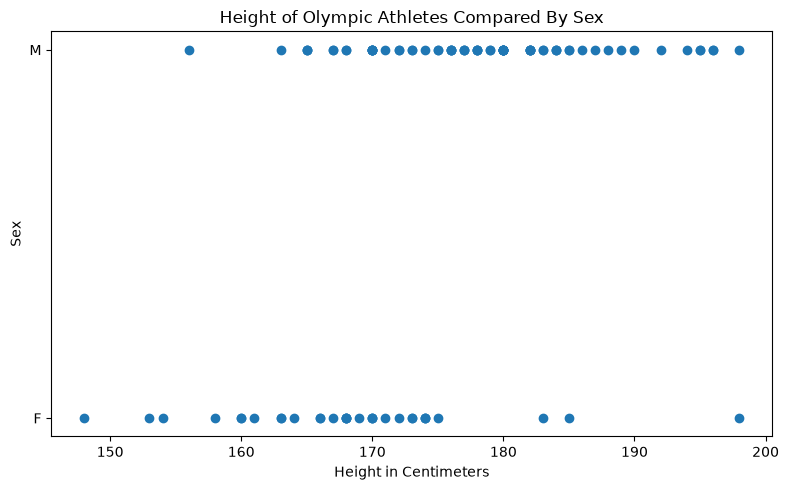

In [31]:
plt.figure(figsize=(8,5))

plt.plot(sampled_olympics['height'], sampled_olympics['sex'], 'o')
plt.xlabel("Height in Centimeters")
plt.ylabel("Sex")
plt.title("Height of Olympic Athletes Compared By Sex")
plt.tight_layout()
plt.show()

While a relatively uninteresting chart, it allows us view the distribution of heights across our gender; here, we can observe a large disparity between our sex heights that favors men. From our random sample of our large dataset, only three of our female athletes was above 182 cm (6'0), while over 10 male athletes were above that measure. A simple plot like this allows us to draw easy comparisons between the differences in heights of our male and female Olympic athletes, while also helping us observe those distributions within each sex as well.

## Part 2: Slope Chart

Next, we'll be using a slope chart to describe changes in certain groups across different periods of time. For this example, we'll have to do a bit more setup; my vision is to sort our dataset by year listed, aggregate the number of total medals earned in that year per athlete, then compare the number of medals won by country across our range of years. Note that we'll now drop NA values from our entire dataset, limiting our table to around 30,000 results; we'll assume that missing values are related to the year they were recorded, so we shouldn't experience any issue performing the following experiment. Furthermore, we'll limit our data to 2000's only (so our chart isn't too muddied):

### Data Setup

In [51]:
new_olympics = cleaned_olympics.dropna().sort_values('year')
new_olympics['noc'] = pd.Categorical(new_olympics['noc'])

slope_olympics = (
    new_olympics.groupby(["year", "season", "noc", "medal"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

slope_olympics['total'] = slope_olympics[['Bronze', 'Silver', 'Gold']].sum(axis = 1)
filtered_slope_olympics = slope_olympics[slope_olympics['year'] >= 2000]

filtered_slope_olympics

medal,year,season,noc,Bronze,Gold,Silver,total
956,2000,Summer,ALG,3,1,1,5
957,2000,Summer,ARG,3,0,17,20
958,2000,Summer,ARM,1,0,0,1
959,2000,Summer,AUS,54,60,69,183
960,2000,Summer,AUT,0,3,1,4
...,...,...,...,...,...,...,...
1464,2016,Summer,UKR,5,2,8,15
1465,2016,Summer,USA,71,138,54,263
1466,2016,Summer,UZB,7,4,2,13
1467,2016,Summer,VEN,2,0,1,3


### Creation of Slope Plot

Now that we've cleaned, filtered, and added totals to our data, let's create a slope plot that compares total medals earned per country based on the year:

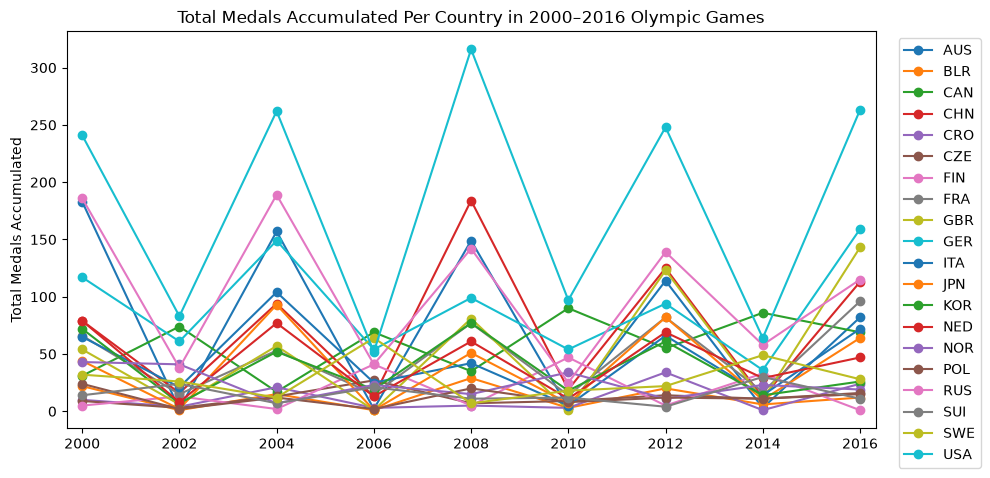

In [77]:
years = sorted(filtered_slope_olympics["year"].unique())

piv = filtered_slope_olympics.pivot(index="noc", columns="year", values="total").dropna()

plt.figure(figsize=(10, 5))
for noc, row in piv.iterrows():       
    plt.plot(row.index, row.values, marker='o', label=noc) 
plt.xticks(years)                      
plt.margins(x=0.02)
plt.ylabel("Total Medals Accumulated")
plt.title("Total Medals Accumulated Per Country in 2000–2016 Olympic Games")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Slight Pivot

Note how our plot is kind of hard to read; yet, one pattern is very clear: every country seems to earn more metals on the "even years" (2000, 2004, 2008, 2012, 2016) than the odd years. This is because those years correspond to the summer olympics, which has significantly more events than the winter olympics (and thus more events to win). To make our graph more legible and powerful, let's limit our data to just Summer Olympics:

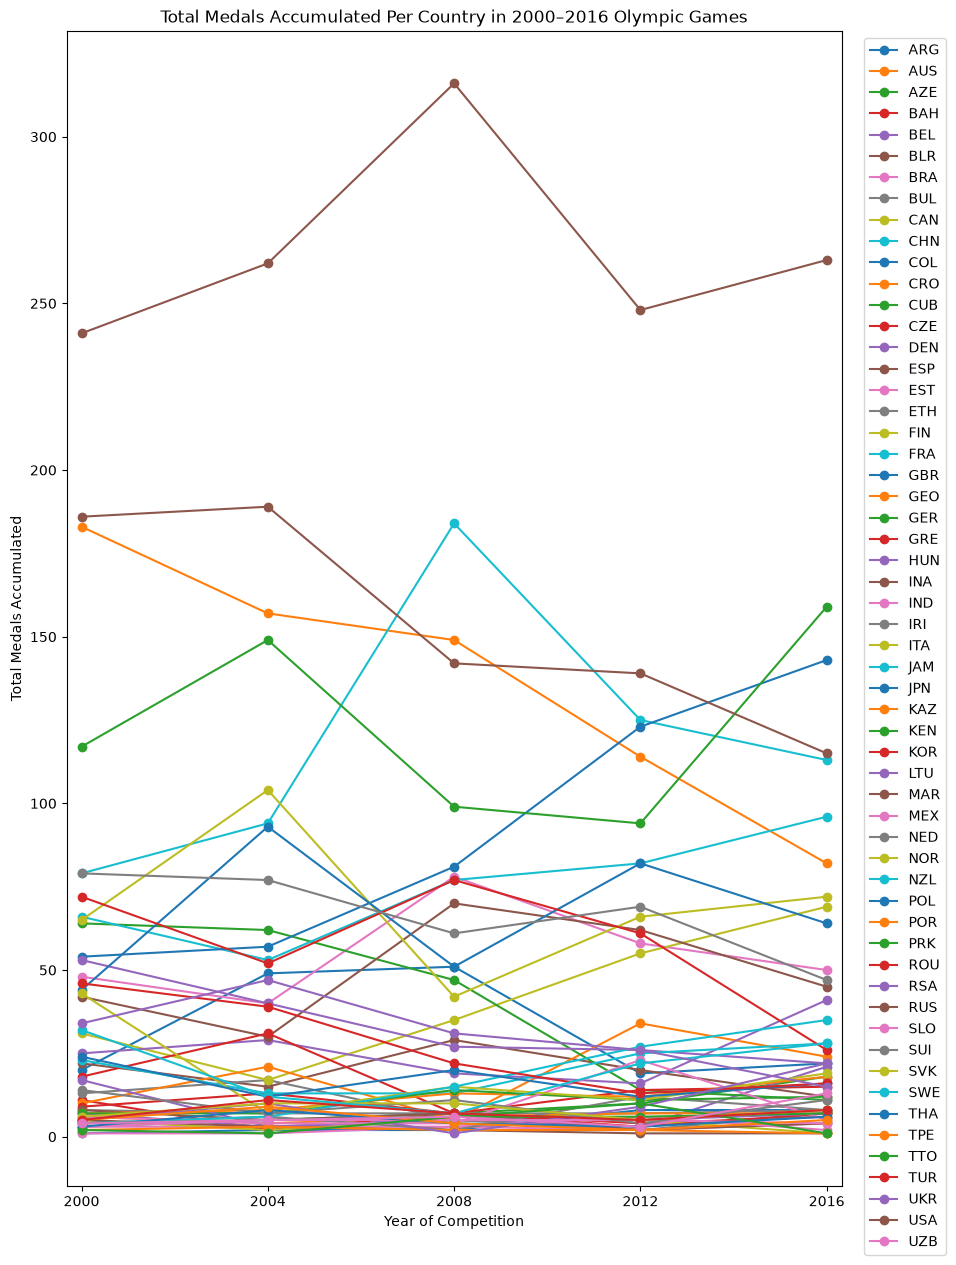

In [88]:
summer_years = [2000, 2004, 2008, 2012, 2016]
new_slope_olympics = filtered_slope_olympics[filtered_slope_olympics['year'].isin(summer_years)]

years = sorted(new_slope_olympics["year"].unique())

piv = new_slope_olympics.pivot(index="noc", columns="year", values="total").dropna()

plt.figure(figsize=(10, 15))
for noc, row in piv.iterrows():       
    plt.plot(row.index, row.values, marker='o', label=noc) 
plt.xticks(years)                      
plt.margins(x=0.02)
plt.xlabel("Year of Competition")
plt.ylabel("Total Medals Accumulated")
plt.title("Total Medals Accumulated Per Country in 2000–2016 Olympic Games")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Despite being a significant improvement over our previous graph, there are still enough countries that regularly compete in the Olympics yet don't consistently earn medals that the bottom half of our graph is very muddy. However, we are now able to more readily observe some powerful trends between the strongest countries in Olympic competition, such as USA's unmatched level of domination in international competition. Clearly, there are far too many countries to compare on one singular plot or axis, so let's use a facet plot (otherwise known as small multiples) to display trends between some of our biggest countries (USA, RUS, GER, GBR) on a country-by-country basis:

## Part 3: Small Multiples Plot

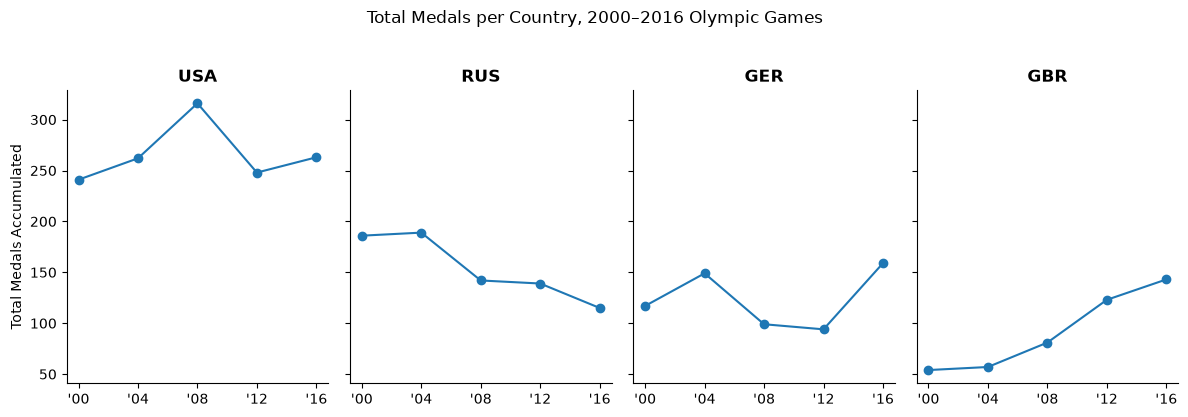

In [113]:
selected_countries = ['USA', 'RUS', 'GER', 'GBR']
years = [2000, 2004, 2008, 2012, 2016]

facet_olympics = new_slope_olympics[new_slope_olympics['noc'].isin(selected_countries)]
piv_facet = facet_olympics.pivot(index="noc", columns="year", values="total").dropna()

fig, axes = plt.subplots(1, len(selected_countries), figsize=(12, 4),
                         sharex=True, sharey=True)

for ax, team in zip(axes, selected_countries):
    if team not in piv_facet.index:      
        ax.set_visible(False)
        continue
    y_vals = piv_facet.loc[team, years].values
    ax.plot(years, y_vals, marker='o')    
    ax.set_title(team, fontsize=12, fontweight='bold')
    ax.set_xticks(years)
    ax.set_xticklabels(["'00", "'04", "'08", "'12", "'16"])  
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel("Total Medals Accumulated")
fig.suptitle("Total Medals per Country, 2000–2016 Olympic Games", y=1.03)
plt.tight_layout()
plt.show()

Finally, we have a somewhat coherent plot! The real strength of the small multiple plots is the ability to line up several charts that share the same x and y axis, so comparisons are made incredibly simple. Also, by limiting our countries to ones that can fit in one row of facet plots, it's super intuitive to just scroll horizontally and draw immediate conclusions about medal accumlation.

## Part 4: Slight Tweak with Normalization

For the final part of this assignment, we'll make a slight tweak to the previous chart by creating a normalized view; my idea for this is to transform our medal accumulated account into a gold medal percentage, so it's more weighted based on the size of the teams. To do this, we'll make a slight tweak to our dataset, repivot, then recreate our small multiples chart:


### Dataset Tweak + Recreation of Plot

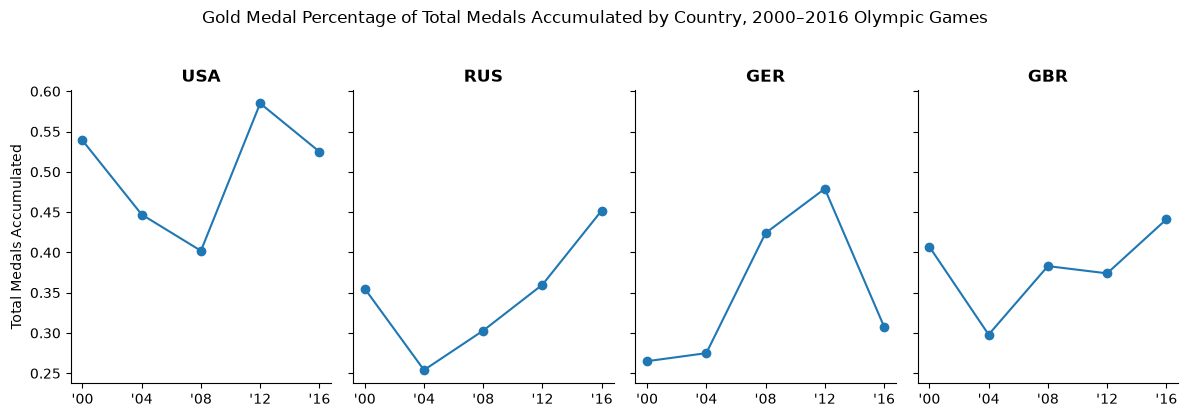

In [122]:
percent_olympics = facet_olympics.assign(GoldPerc = round(facet_olympics['Gold']/facet_olympics['total'], 3))

piv_facet_2 = percent_olympics.pivot(index="noc", columns="year", values="GoldPerc").dropna()

fig, axes = plt.subplots(1, len(selected_countries), figsize=(12, 4),
                         sharex=True, sharey=True)

for ax, team in zip(axes, selected_countries):
    if team not in piv_facet_2.index:      
        ax.set_visible(False)
        continue
    y_vals = piv_facet_2.loc[team, years].values
    ax.plot(years, y_vals, marker='o')    
    ax.set_title(team, fontsize=12, fontweight='bold')
    ax.set_xticks(years)
    ax.set_xticklabels(["'00", "'04", "'08", "'12", "'16"])  
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel("Total Medals Accumulated")
fig.suptitle("Gold Medal Percentage of Total Medals Accumulated by Country, 2000–2016 Olympic Games", y=1.03)
plt.tight_layout()
plt.show()

Here, we notice that gold medal percentage presents a far more variable and spread out dataset of values for our 4 main olympic countries. This is likely indicative of the fact that total medals accumulated isn't exactly indicative of a country's unified strength, but rather their magnitude (how many teams/individuals they submit to each competition, for larger countries like these they are much more likely to have more chances to win medals). However, by using gold percentage, we isolate what is essentially a concentrated strength statistic, which tells us what percentage of a country's medal finishes were the top of their class. In the future, I'd like to potentially layer total medal accumulation and gold medal percentage together to see if there are any overlapping patterns.

## Conclusion

Overall, this assignment was a great exercise in using data visualization techniques to compare groups, which to me is one of the most powerful and valuable purposes of data visualization. While we tried differentiating groups using color encodings and separated axes, I feel like the strongest method of comparing multiple groups in a dataset is using a small multiples/facet plot with shared axes, since we can directly juxtapose different group trends side-to-side using the same reference axes. I plan on exploring more of these comparative graphs in my future projects, such as stacked plots or Cleveland plots.